# Digital Trace Data - Lab 2: User-Centric Approaches

In this lab we will focus on user-centric approaches, and you will be able to analyze your very on digital trace data.

To start, save a copy of this notebook in your own Drive by clicking on *File*, then selecting *Save a copy in Drive* and opening this copy in a new tab. See last week's lab for more details.

## Part 1: Using Zeeschuimer

In the first part of this week's lab you will be able to collect your very own data using the [Zeeschuimer](https://github.com/digitalmethodsinitiative/zeeschuimer) browser extension. With Zeeschuimer you can collect data from different plattforms, such as TikTok, Instagram or Twitter (X).




In order to use Zeeschuimer, there are a couple of steps you need to follow:



1.   Download and install Firefox. If don't already have the Firefox browser installed, do so through [this link](https://www.mozilla.org/en-US/firefox/new/). Next, run the installation.
2.   Open Firefox and download the Zeeschuimer Firefox Extension through [this link](https://tools.digitalmethods.net/zeeschuimer) (open the link in your Firefox browser). A window will pop up on the top right of your browser. Click "Continue to Installation" and "Add". You can check if the installation worked by clicking on the puzzle icon on the top left. If Zeeschuimer appears, then you are good to go.



<div>
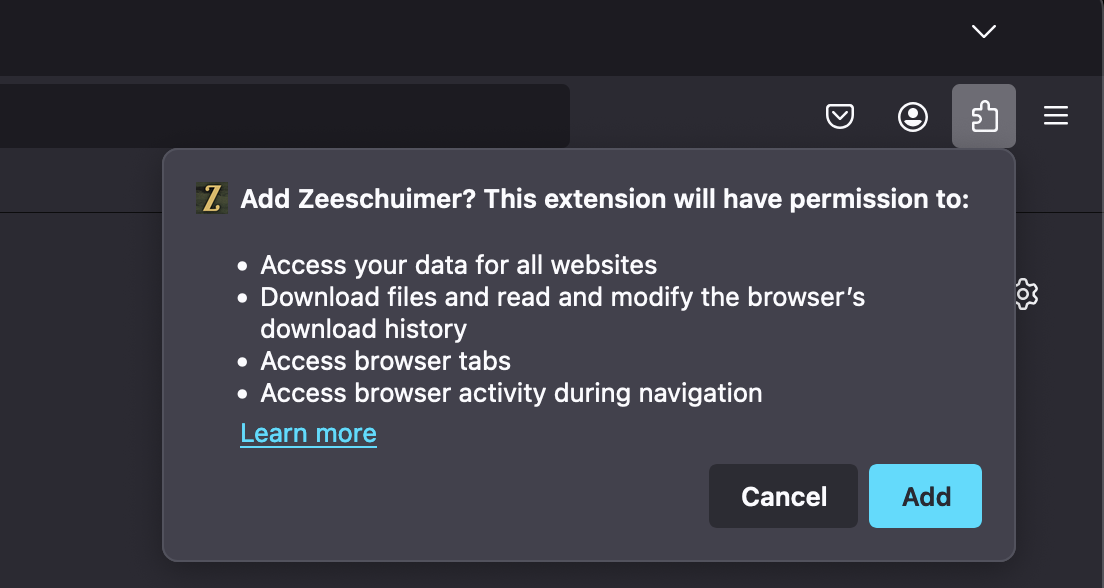
</div>

3. Click on Zeeschuimer to open the Zeeschuimer interface. Enable capturing for TikTok posts and comments as in the screenshot below.


<div>
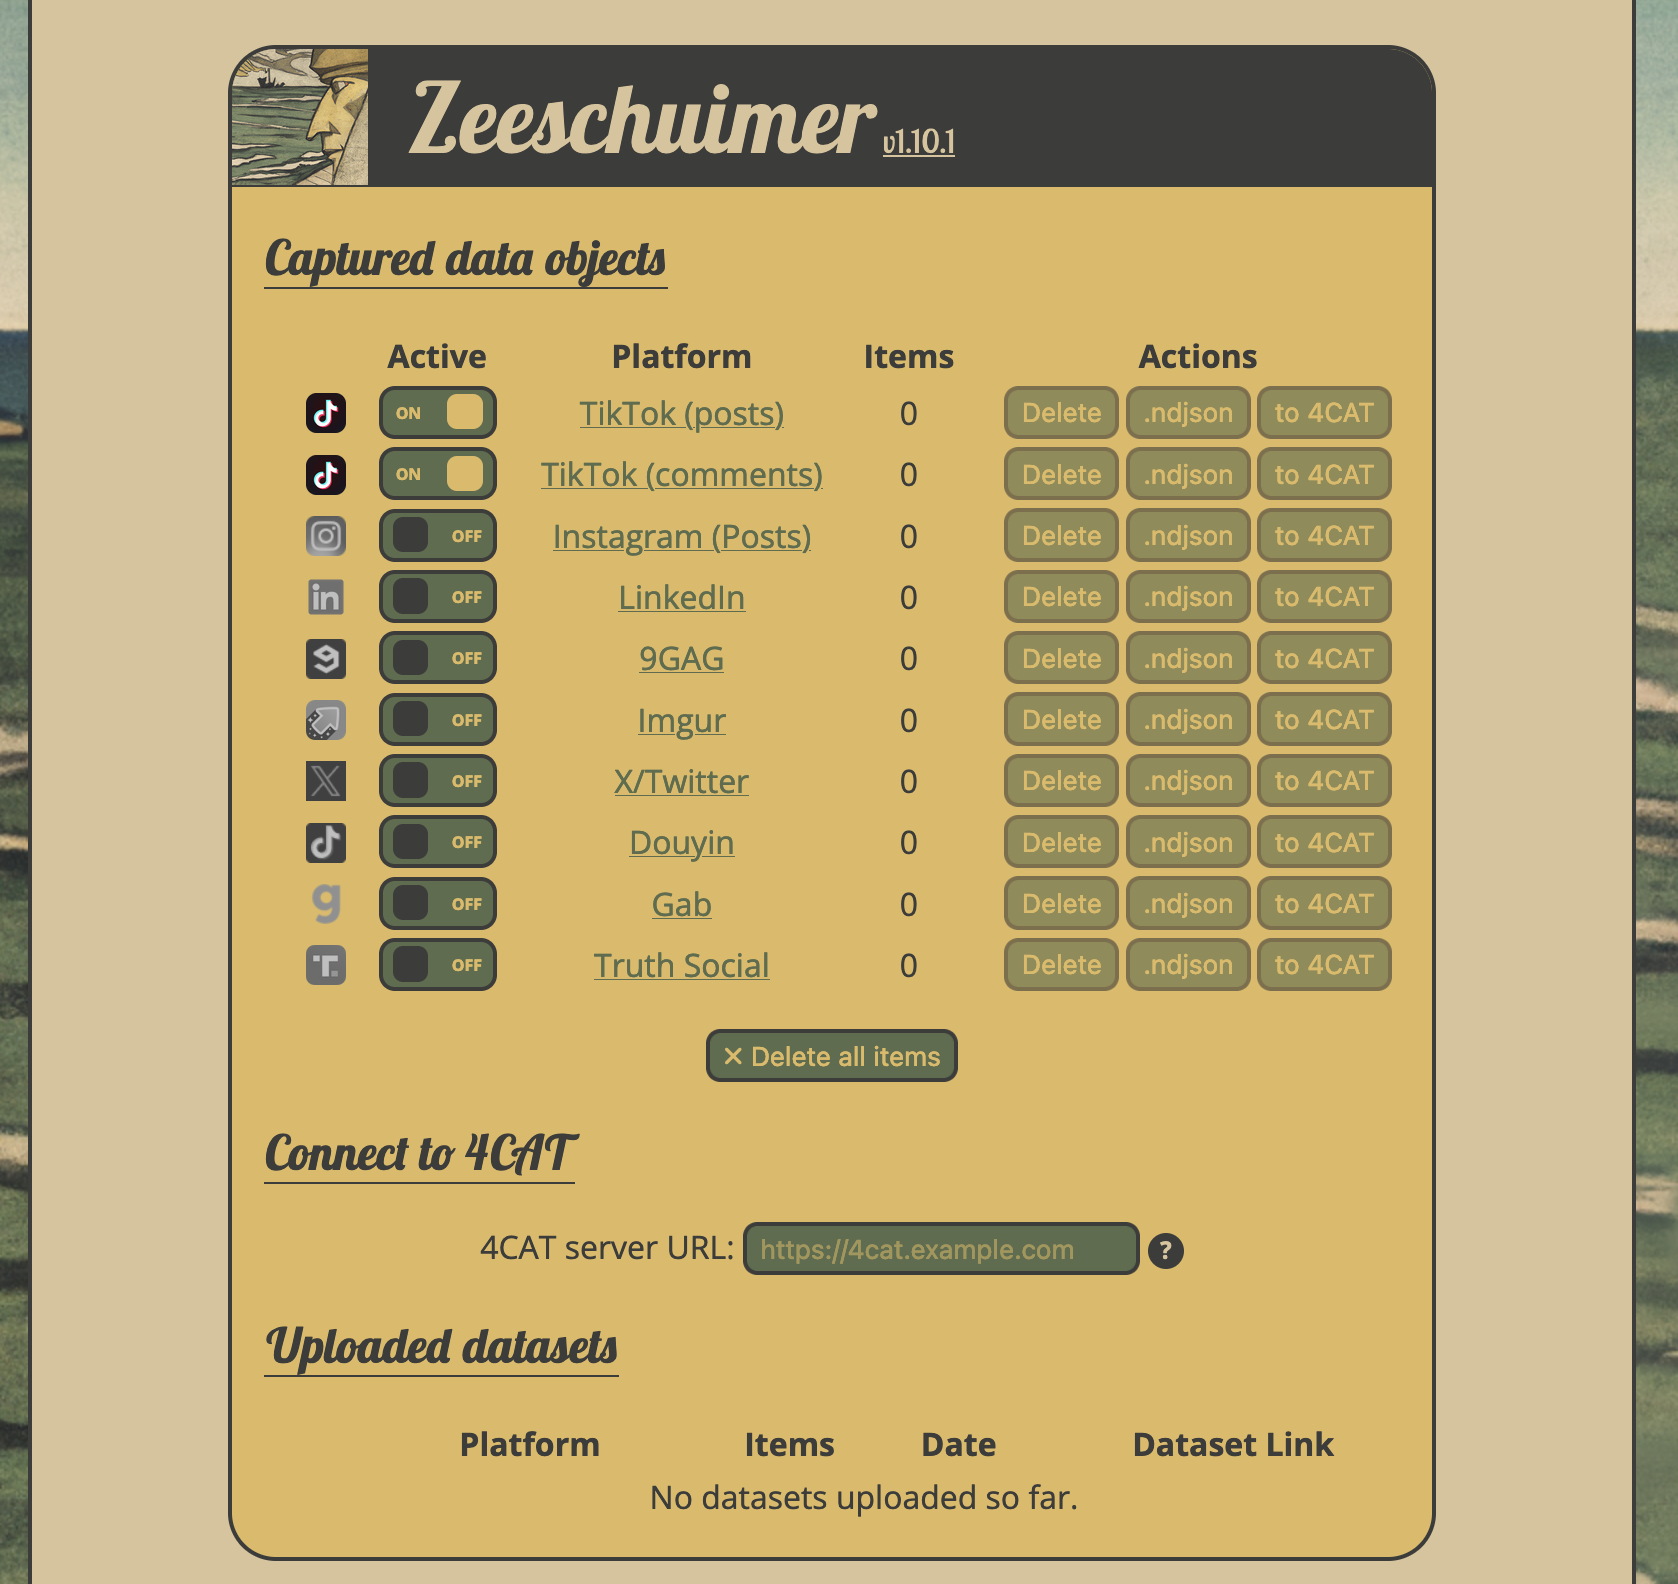
</div>

4.	Now, Zeeschuimer will capture the Posts and Comments you see come by when you browse through TikTok.
5.	Go to https://www.tiktok.com/foryou in the Firefox browser. If you have a TikTok account, it is preferred to log in (so you can answer the bonus question), but you will also be able to continue if you don’t have an account. Once the TikTok for you page is opened, browse through videos using the arrows on the right. Fast or slow, click through using the arrows until you have watched about 100 videos.

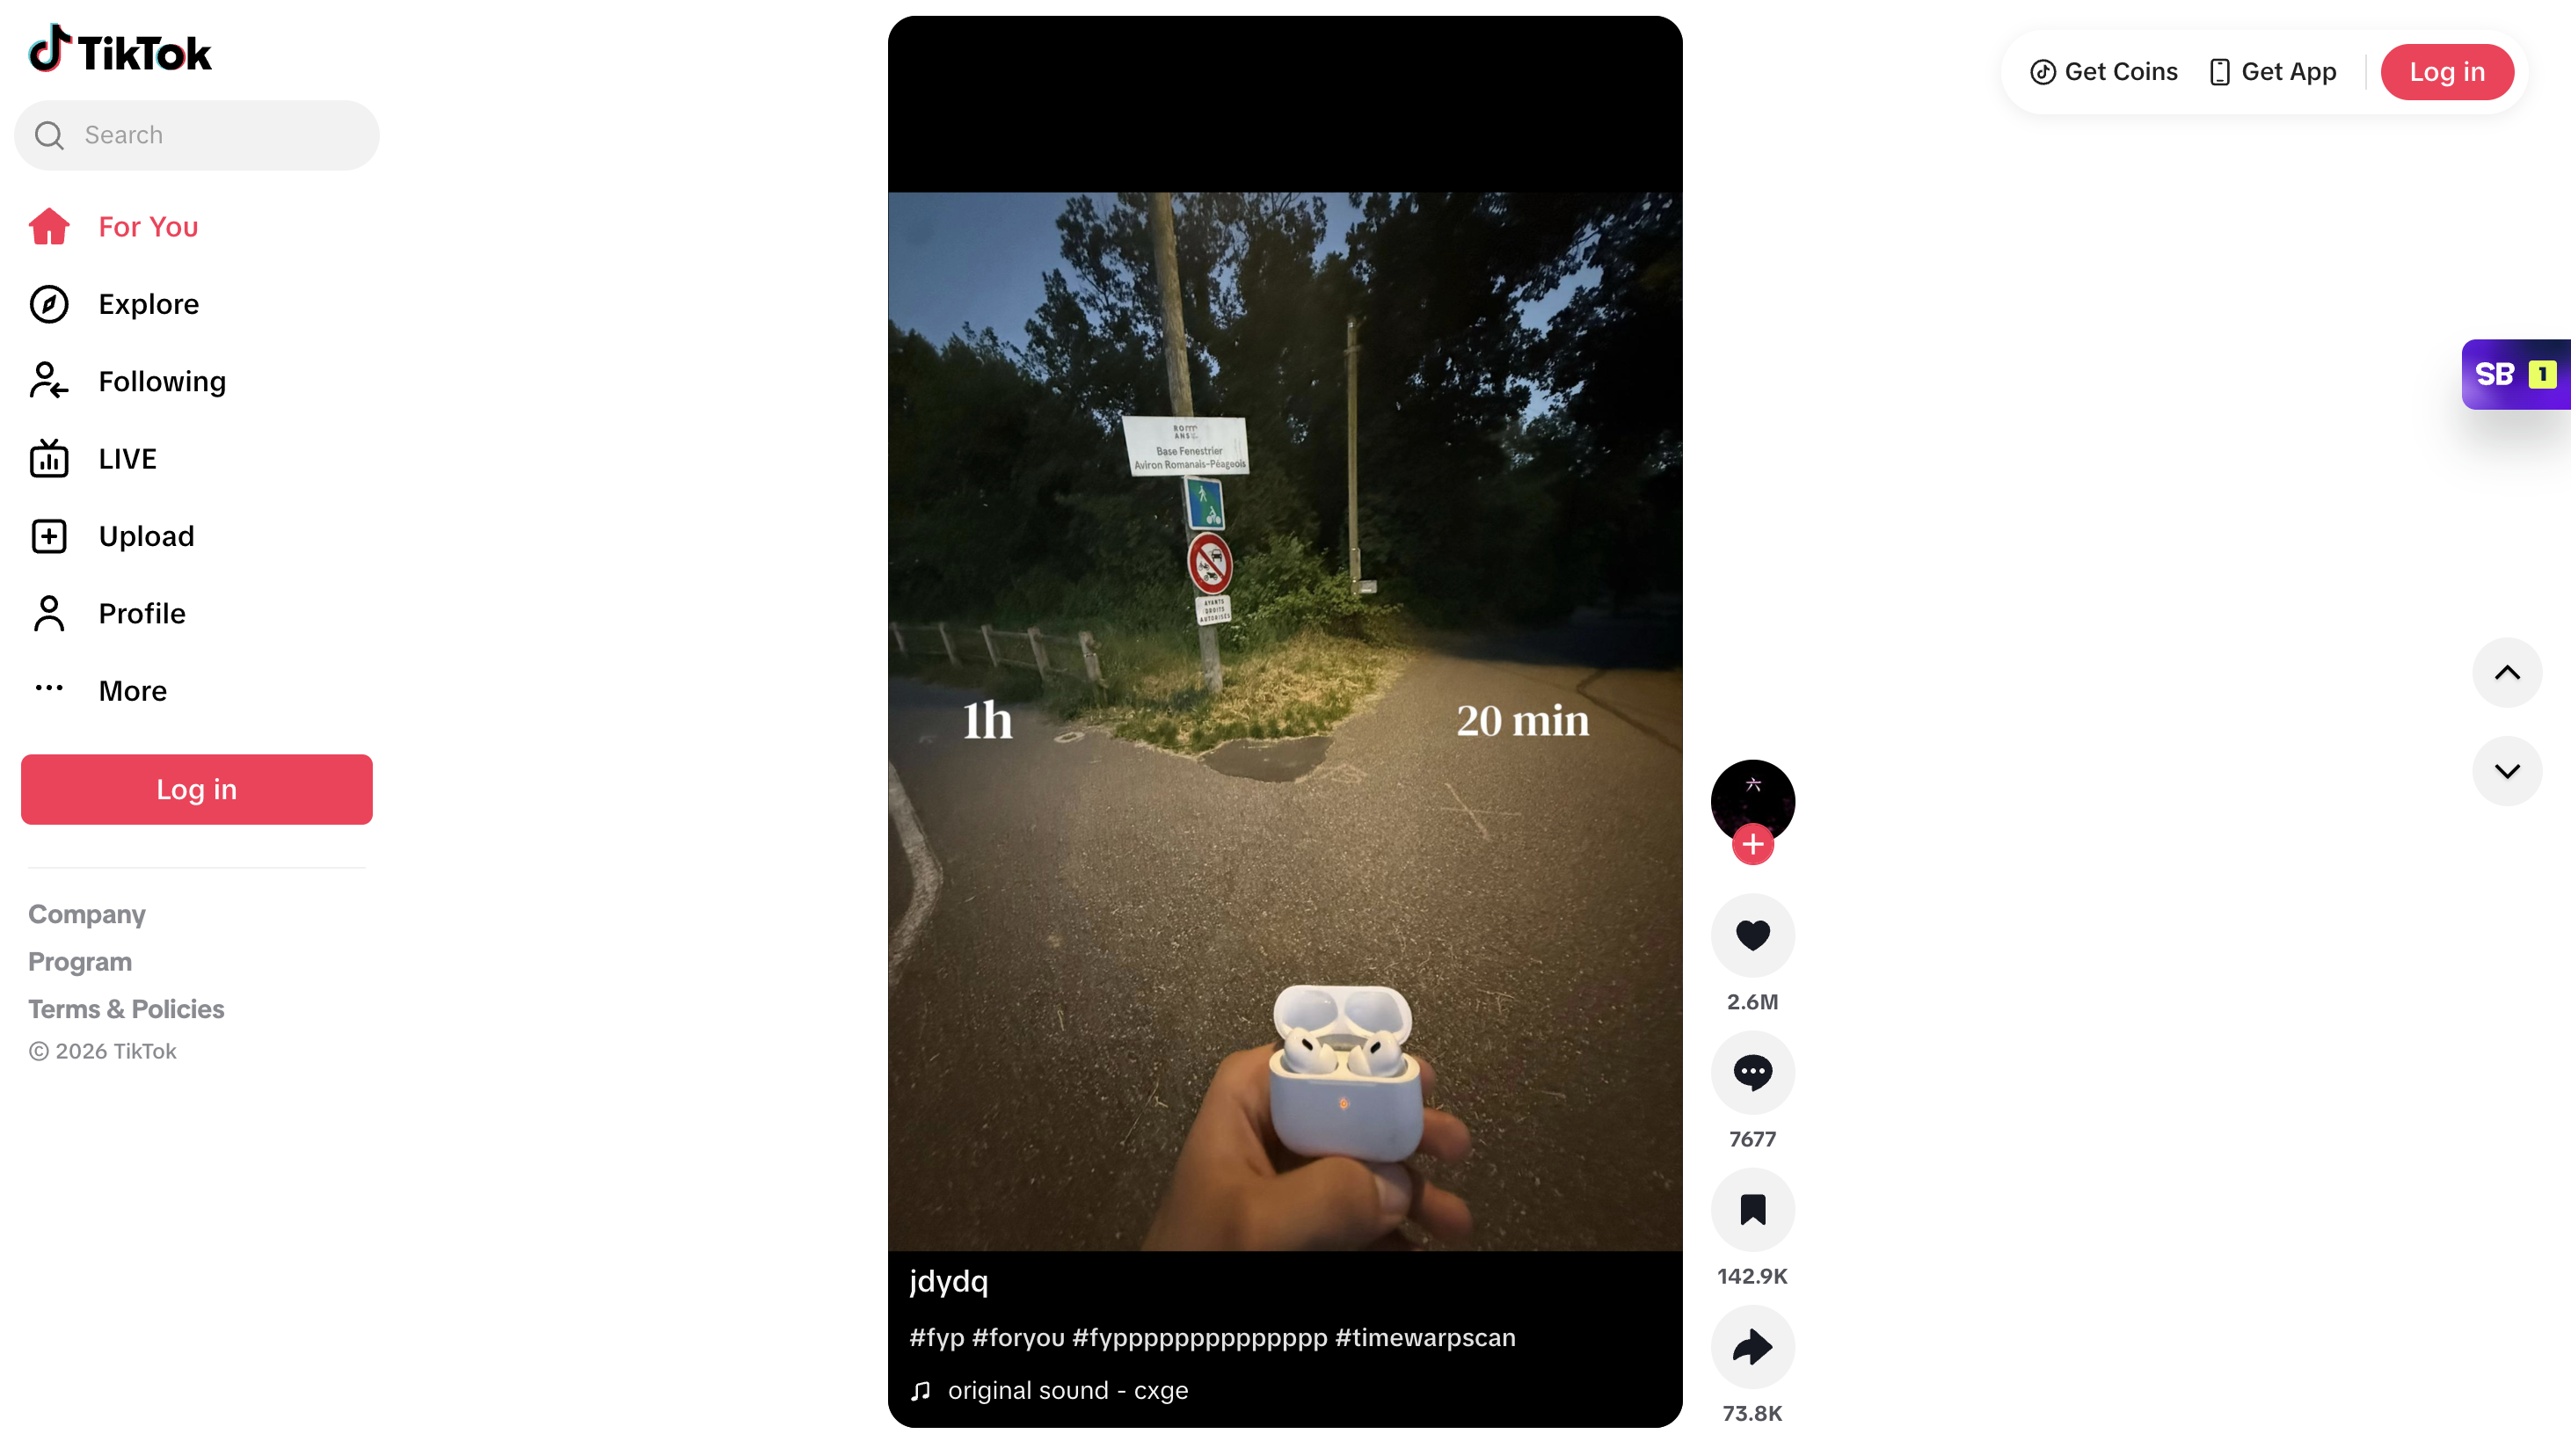

6.	Now open Zeeschuimer by clicking the puzzle piece icon. Then, under the Actions column, hover over Download and click the .ndjson button for the TikTok posts. Now you can save this file on your computer.
7.	Upload the zeeschuimer export file to your Google Colab by clicking on the files icon on the left, right-clicking on *sample_data* and selecting *Upload*.

<div>
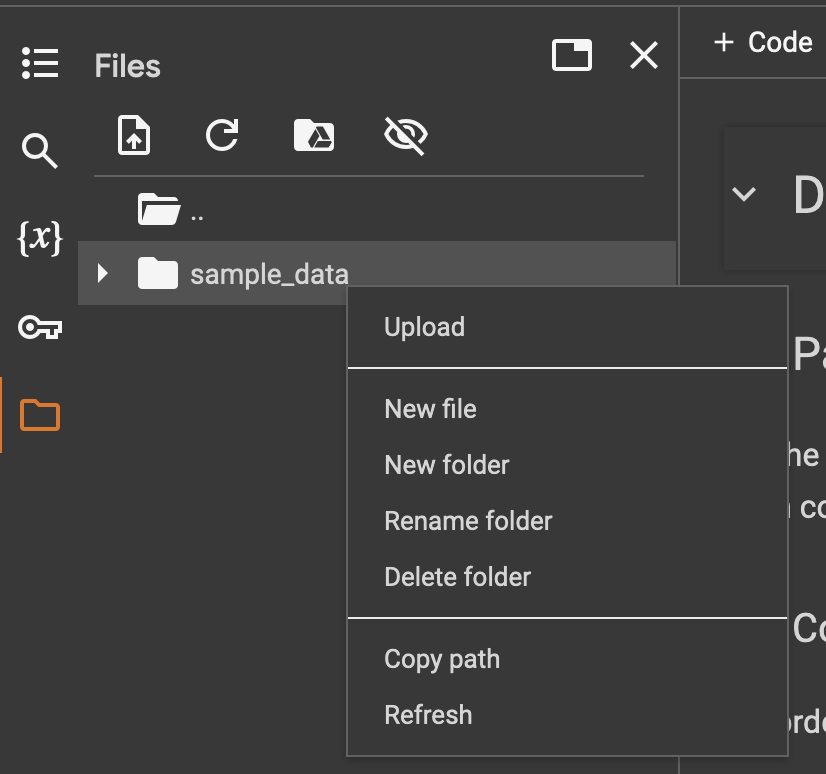
</div>

8.	Now select your Zeeschuimer file and upload it. Now, wait for a couple of seconds until the file is uploaded. Then, click on the arrow left of *sample_data*, right-click on your Zeeschuimer file, and select copy path. Lastly, paste the copied path into for *PLACEHOLDER_PATH* in the code below.



<div>
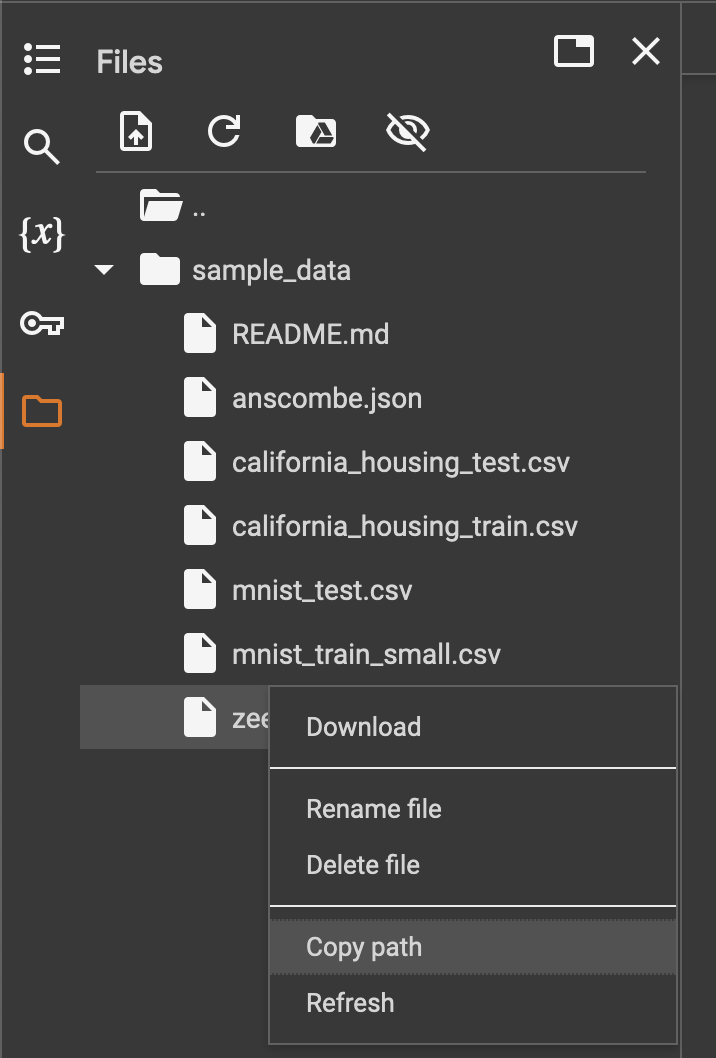
</div>


### Reading in the Data

In order to analyze the data, we first have to read it in.

In [ ]:
# Load downloaded file
import pandas as pd
df = pd.read_json("PLACEHOLDER_PATH", lines=True)
print(df.head())

We can next inspect the structure of the data frame created by Zeeschuimer. As we can see, this structure is quite complicated to analyze right away.

In [ ]:
df.head()

Most important information is saved in the column `data`. Thus, we can normalize the data set.

In [ ]:
# Normalize data
data_normalized = pd.json_normalize(df['data'])
pd.options.display.max_columns = 100
# Print first lines
data_normalized.head(20)["desc"].values

We can next look at the names of the columns the newly created data set contains.

In [ ]:
# Retrieve column name for every column in normalized data frame
column_names = [col.split()[0] for col in data_normalized.columns]
print(column_names) # print names

In [ ]:
# print first lines
print(data_normalized.head)

## Part 2: Analyzing the Zeeschuimer Data

### Question 1: Run the code below. How many rows and how many columns does the data set contain? What do they represent?

In [ ]:
print(data_normalized.shape)

*ADD YOUR ANSWER HERE*

### Question 2: The code below prints the first 10 column names. What do these columns represent?

In [ ]:
column_names = [col.split()[0] for col in data_normalized.columns]
print(column_names[0:10])

*ADD YOUR ANSWER HERE*

### Question 3: We are now going to explore if searching for specific interests influences the data you see. First have a look at the column “Contents” by creating a word cloud with the code below. What are some frequently seen words here?

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Extract the descriptions from the main DataFrame
descriptions = data_normalized['desc']

# Combine all 'desc' values into one string
combined_desc = ' '.join(descriptions.dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_desc)

# Display the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

*ADD YOUR ANSWER HERE*

### Question 4: Now search for the term “Politics” and browse through the videos like we just did before. After you scrolled through about a 100 videos, again save the .ndjson file and open it in this notebook by following the steps described in Part 1. Paste the new path into *PLACEHOLDER_PATH* and run the code below.

In [ ]:
df_politics = pd.read_json("PLACEHOLDER_PATH", lines=True)
print(df.head())

# Normalize data
data_politics_normalized = pd.json_normalize(df['data'])
pd.options.display.max_columns = 100
# Print first lines
data_politics_normalized.head(20)["desc"].values

*ADD YOUR ANSWER HERE*

### Question 5: Now again look at the frequent terms in the column “Contents” by running the code below. How has  this wordcloud changed in comparison to the first? What terms do you see that are new?

In [ ]:
# Extract the descriptions from the main DataFrame
descriptions = data_politics_normalized['desc']

# Combine all 'desc' values into one string
combined_desc = ' '.join(descriptions.dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_desc)

# Display the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

*ADD YOUR ANSWER HERE*

### Bonus Question: This one you can only do if you  have signed into TikTok. Go to your “for you” page, and again watch about 100 videos. Now save and load the .ndjson file again. What is now the frequency for the term “Politics”?

In [ ]:
df_foryou = pd.read_json("PLACEHOLDER_PATH", lines=True)
print(df.head())

# Normalize data
data_foryou_normalized = pd.json_normalize(df_foryou['data'])
pd.options.display.max_columns = 100
# Print first lines
data_foryou_normalized.head(20)["desc"].values

# Extract the descriptions from the main DataFrame
descriptions = data_foryou_normalized['desc']

# Combine all 'desc' values into one string
combined_desc = ' '.join(descriptions.dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_desc)

# Display the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Part 3: Analyzing Your Own Digital Trace Data

We are now going to inspect our own digital trace data. You can choose to inspect data from ChatGPT, YouTube or Instagram. If you choose to look into YouTube or Instagram, you have likely already requested your data last week. Please go to our [Digital Footprint Explorer](https://d3i-infra.github.io/dd-education/) to continue. We expect you to explore data from at least two out of three platforms.

### ChatGPT

Click on ChatGPT in the list of platforms to choose from. Next, request and store the digital copy of your personal data that you receive from ChatGPT.

Go to the next page and open the ChatGPT file. Here you see a table.

#### Question 1: How many rows and how many columns does this table have?

*ADD YOUR ANSWER HERE*

#### Question 2: Explain in your own words what you can find in the columns and what in the rows?

*ADD YOUR ANSWER HERE*

#### Question 3: In this table, you can find the information that is present in the file “user.json”. If you don't see it on the first page, you can use the search box on the upper right corner. What information is extracted from this file that would allow to identify to which person this data belongs?

*ADD YOUR ANSWER HERE*

#### Question 4: Are there any other places where identifying information can be found in this data? Tip: use the “search” box on the upper right corner of the screen.

*ADD YOUR ANSWER HERE*

#### Question 5: Did you know that ChatGPT collected this data about you? What were your expectations on this?

*ADD YOUR ANSWER HERE*

#### Press the button “Continue”. You now see a table that only contains the conversations you had with ChatGPT. Below the table, you find a wordcloud of these conversations that should give you an idea of the topics that you most frequently discuss with ChatGPT.

#### Question 6: If you think about the conversations you had with ChatGPT. To what extent is this memory that you had represented by this wordcloud? What are differences that you see and what can be the cause of this difference?

*ADD YOUR ANSWER HERE*

### YouTube
Click on YouTube in the list of platforms to choose from. Next, request and store the digital copy of your personal data that you receive from YouTube.


Go to the next page and open the YouTube file. Here you see a number of tables and figures. Have a look at the first table.


#### Question 1: How many rows and how many columns does this table have?

*ADD YOUR ANSWER HERE*

#### Question 2: Explain in your own words what you can find in the columns and what in the rows?

*ADD YOUR ANSWER HERE*

#### Question 3: Is there any information in this table that would allow to identify to which person this data belongs? Browse through table and use the “Search” box on the top right of the page to investigate this. Describe the search terms that you use here to figure this out.

*ADD YOUR ANSWER HERE*

#### Question 4: If a random person would obtain the data that you see in these tables, do you think they would be able to figure out this data belonged to you? Why (not)?

*ADD YOUR ANSWER HERE*

#### Question 5: Below the table, you find a figure that illustrated how many videos you have watched per month since you started using this account. When did you first start using this account and how would you describe the trend that you see here? Note that if you indicated that YouTube should automatically delete your watch history after a certain period, you should only see that period. Confirm if this matches with your settings.

*ADD YOUR ANSWER HERE*

#### Question 6: Try to remember your own YouTube watch history. To what extent is this memory that you had represented by the data in these tables and figures? What are differences that you see and what can be the cause of these differences?

*ADD YOUR ANSWER HERE*

#### Question 7: Now look at the wordcloud that is presented representing your YouTube search history. Compare this wordcloud with the wordcloud representing your YouTube watch history. What are notable differences. How do you think these differences are caused?

*ADD YOUR ANSWER HERE*

### Instagram

Click on Instagram in the list of platforms to choose from. Next, request and store the digital copy of your personal data that you receive from Instagram.

Go to the next page and open the Instagram file. Here you see a Table.


#### Question 1: How many rows and how many columns does this table have?

*ADD YOUR ANSWER HERE*

#### Question 2: Explain in your own words what you can find in the columns and what in the rows?

*ADD YOUR ANSWER HERE*

#### Question 3: Is there any information in this table that would allow to identify to which person this data belongs? Browse through table and use the “Search” box on the top right of the page to investigate this. Describe the search terms that you use here to figure this out.

*ADD YOUR ANSWER HERE*

#### Question 4: If a random person would obtain the data that you see in these tables, do you think they would be able to figure out this data belonged to you? Why (not)?

*ADD YOUR ANSWER HERE*

#### Question 5: Click on “Continue” to find more data. Below the table “Posts viewed on Instagram”, you find two figures. The first one illustrates how many posts you viewed per moment of the day. At what period were you watching the most posts? Does this correspond to how you remember your Instagram use?

*ADD YOUR ANSWER HERE*

#### Question 6: Under the header “Comments on Instagram posts”, you find a wordcloud words you used most often in comments on posts. What words did you use most often and to what extend does this correspond to what you remember? How would you describe the sentiment?

*ADD YOUR ANSWER HERE*

#### Question 7: Under “Instagram liked posts”, you find a wordcloud with the accounts which you gave the most likes. How would you describe the group of accounts that you see here? To what extent does this correspond to what you remember?  

*ADD YOUR ANSWER HERE*

## Part 4: Questions about the Literature


#### Question 1: In Chapter 1 of *Data Collection with Wearables, Apps, and Sensors* (pages 2-4), a list of studies utilizing wearables, apps, and sensors for data collection is provided. What potential errors could affect the study conducted by Mackerron and Mourato (2013)?

*ADD YOUR ANSWER HERE*

#### Question 2: What potential errors could affect the study conducted by Sugie and Lens (2017)?

*ADD YOUR ANSWER HERE*

#### Question 3: Define an environmental sensor and explain why these will not be discussed in this course.

*ADD YOUR ANSWER HERE*

#### Question 4: When participants are asked to take a photo of their receipt, is this type of data collection considered passive or active? Is it classified as a digital trace?

*ADD YOUR ANSWER HERE*

#### Question 5: When participants are asked to install an app that tracks their location on their phone, is this type of data collection considered passive or active? Additionally, is it classified as a digital trace?

*ADD YOUR ANSWER HERE*

#### Question 6: Some studies require participants to use their own devices, while others provide devices to participants. Identify three significant differences between these approaches, considering potential errors, costs, and the distinction between active and passive data collection.

*ADD YOUR ANSWER HERE*